In [ ]:
%%capture
! wget https://archive.ics.uci.edu/static/public/186/wine+quality.zip
! unzip wine+quality.zip

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn import model_selection
from sklearn import tree

import matplotlib.pyplot as plt

# Pruebas de sobreajuste y subajuste

In [ ]:
df_1 = pd.read_csv("winequality-white.csv", sep=";")
df_1["type"] = 0
df_2 = pd.read_csv("winequality-red.csv", sep=";")
df_2["type"] = 1
df = pd.concat([df_1, df_2])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


In [ ]:
df.shape

(6497, 13)

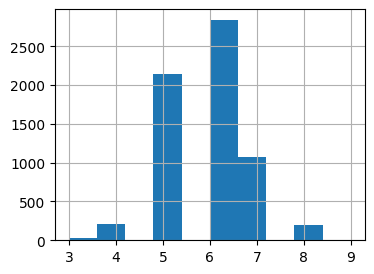

In [ ]:
df["quality"].hist(figsize=(4,3));

In [ ]:
X = df.drop(columns=["quality"])
y = df["quality"]

X.shape, y.shape

((6497, 12), (6497,))

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5197, 12), (1300, 12), (5197,), (1300,))

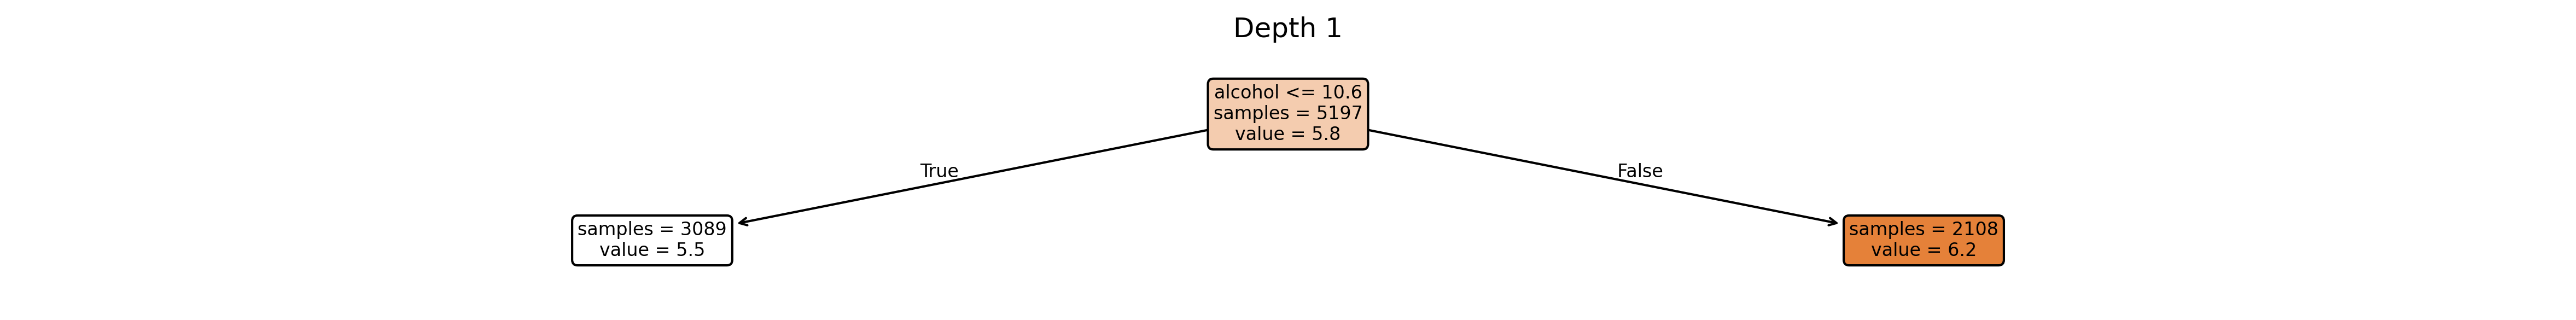

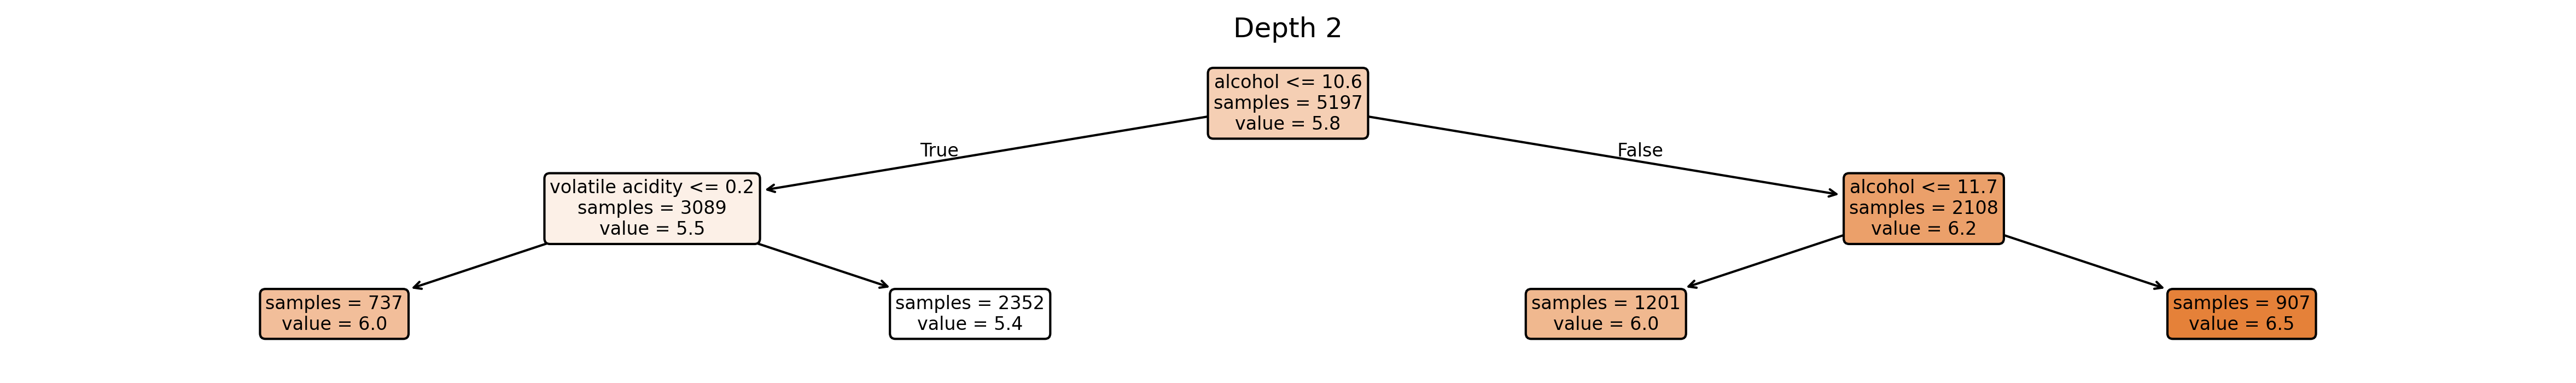

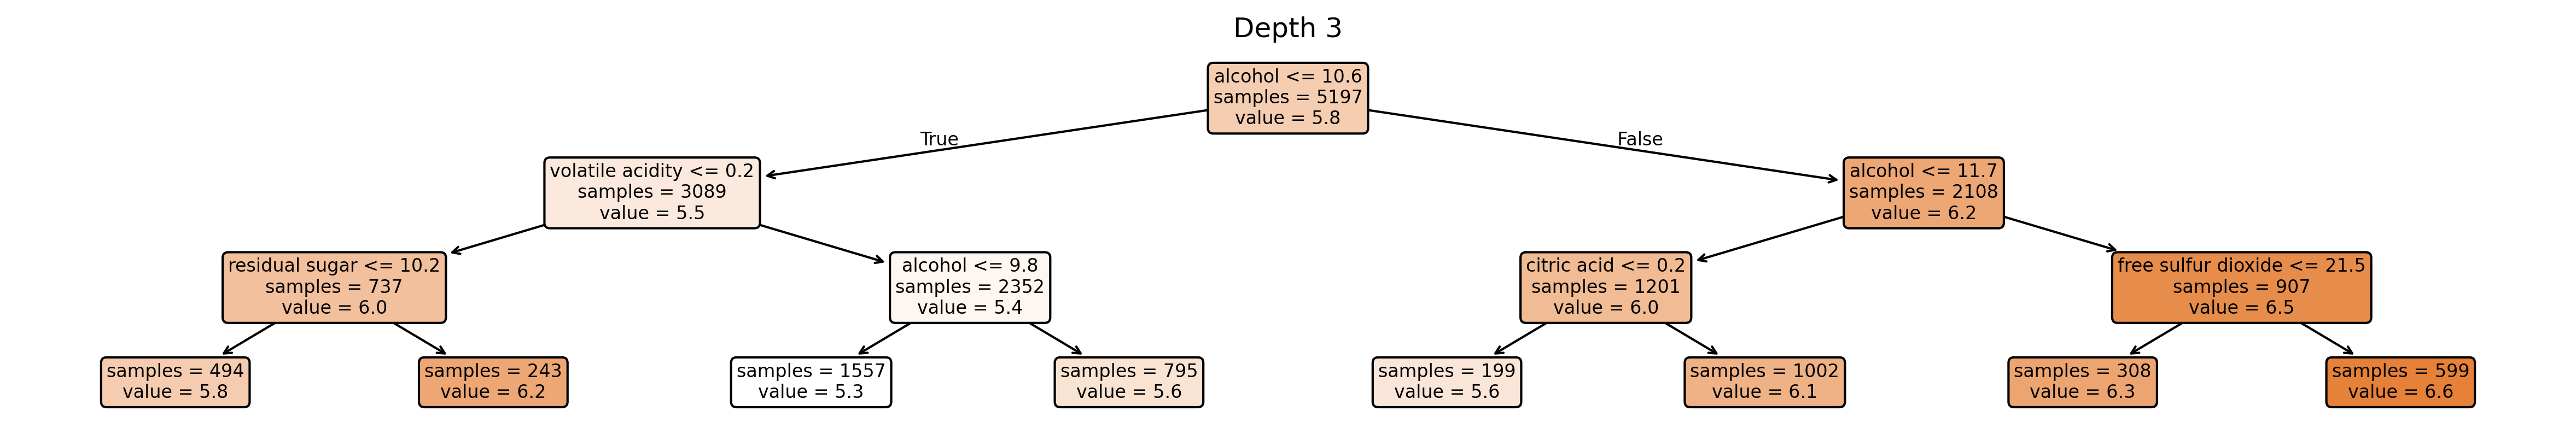

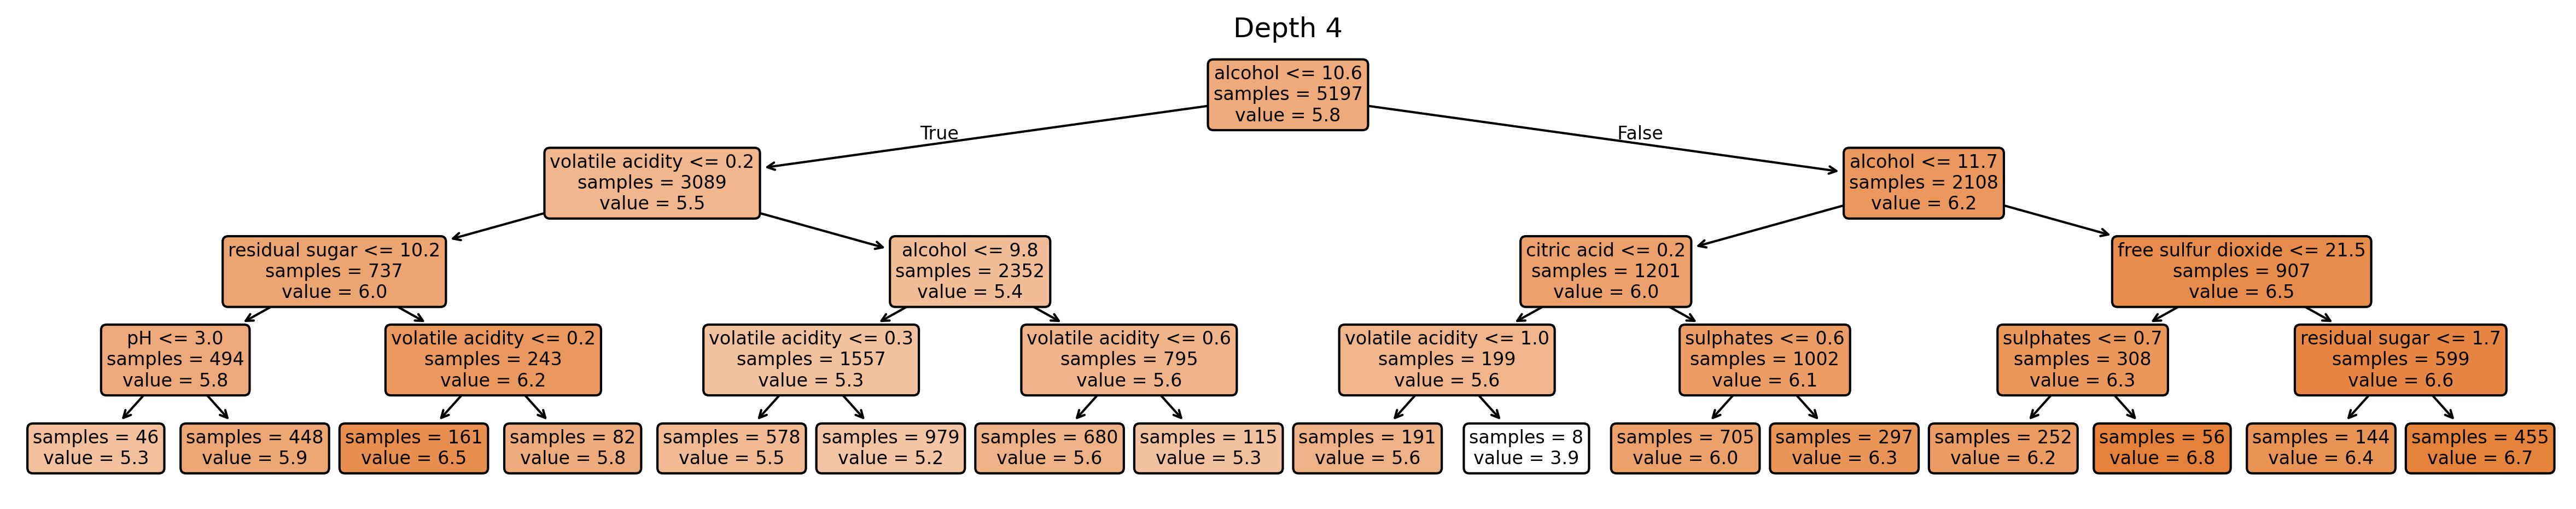

In [ ]:
for depth in range(1, 4+1):
    plt.figure(figsize=(20, 0.5*depth+1.5), dpi=300)

    clf = sk.tree.DecisionTreeRegressor(max_depth=depth)
    clf.fit(X_train, y_train);
    sk.tree.plot_tree(clf, feature_names=X_train.columns.tolist(), filled=True, rounded=True, impurity=False, precision=1, fontsize=8)
    plt.title(f'Depth {depth}')
    plt.show()

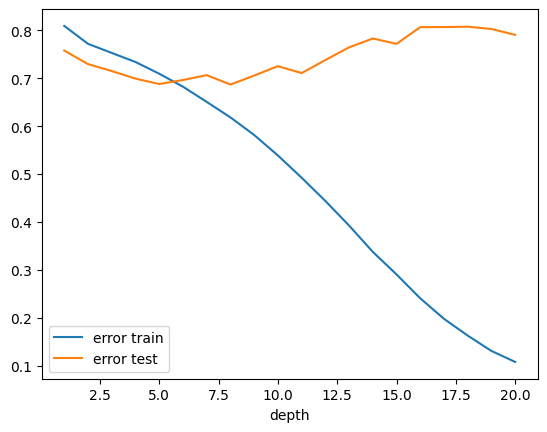

In [ ]:
scores = []

for depth in range(1, 20+1):
    clf = sk.tree.DecisionTreeRegressor(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train);
    scores.append({
        "depth": depth,
        "error train": sk.metrics.root_mean_squared_error(y_train, clf.predict(X_train)),
        "error test": sk.metrics.root_mean_squared_error(y_test, clf.predict(X_test))
    })

scores_df = pd.DataFrame(scores)
scores_df.plot(x="depth", y=["error train", "error test"], );


In [ ]:
scores = []

for depth in range(1, 21+1):
    clf = sk.tree.DecisionTreeRegressor(max_depth=depth, random_state=42)

    scores = -1*sk.model_selection.cross_val_score(clf, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    print(f"{depth=:2d} mean={scores.mean():0.3f} std={scores.std():0.3f}")



depth= 1 mean=0.813 std=0.008
depth= 2 mean=0.779 std=0.011
depth= 3 mean=0.761 std=0.016
depth= 4 mean=0.754 std=0.016
depth= 5 mean=0.749 std=0.015
depth= 6 mean=0.746 std=0.017
depth= 7 mean=0.757 std=0.018
depth= 8 mean=0.766 std=0.025
depth= 9 mean=0.775 std=0.023
depth=10 mean=0.796 std=0.020
depth=11 mean=0.808 std=0.028
depth=12 mean=0.827 std=0.028
depth=13 mean=0.841 std=0.032
depth=14 mean=0.845 std=0.026
depth=15 mean=0.856 std=0.022
depth=16 mean=0.867 std=0.026
depth=17 mean=0.875 std=0.014
depth=18 mean=0.874 std=0.026
depth=19 mean=0.876 std=0.014
depth=20 mean=0.875 std=0.011
depth=21 mean=0.880 std=0.017


# Pruebas sobre los datos

In [ ]:
df_1 = pd.read_csv("winequality-white.csv", sep=";")
df_1["type"] = 0
df_2 = pd.read_csv("winequality-red.csv", sep=";")
df_2["type"] = 1
df = pd.concat([df_1, df_2])

In [ ]:
X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [ ]:
clf = sk.tree.DecisionTreeRegressor(max_depth=6, random_state=42)

## Variamos la cantidad de datos

In [ ]:
for sample_frac in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    X_train_sample = X_train.sample(frac=sample_frac, random_state=42)
    y_train_sample = y_train.iloc[X_train_sample.index]

    clf.fit(X_train_sample, y_train_sample)
    rmse = sk.metrics.root_mean_squared_error(y_test, clf.predict(X_test))
    print(f"{sample_frac=:0.1f} {rmse=:0.3f}")

sample_frac=0.1 rmse=0.975
sample_frac=0.2 rmse=1.013
sample_frac=0.3 rmse=0.921
sample_frac=0.4 rmse=0.917
sample_frac=0.5 rmse=0.881
sample_frac=0.6 rmse=0.869
sample_frac=0.7 rmse=0.858
sample_frac=0.8 rmse=0.865
sample_frac=0.9 rmse=0.855
sample_frac=1.0 rmse=0.872


## Variamos la cantidad de columnas

In [ ]:
X = df.drop(columns=["quality"])
y = df["quality"]

for sample_n in range(1, X.shape[1]+1):
    X_sample = X.sample(n=sample_n, axis=1, random_state=42)

    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X_sample, y, test_size=0.2, shuffle=True, random_state=42)

    clf.fit(X_train, y_train)
    rmse = sk.metrics.root_mean_squared_error(y_test, clf.predict(X_test))
    print(f"{sample_n=:02d} {rmse=:0.3f}")

sample_n=01 rmse=0.732
sample_n=02 rmse=0.739
sample_n=03 rmse=0.738
sample_n=04 rmse=0.737
sample_n=05 rmse=0.725
sample_n=06 rmse=0.712
sample_n=07 rmse=0.694
sample_n=08 rmse=0.692
sample_n=09 rmse=0.695
sample_n=10 rmse=0.695
sample_n=11 rmse=0.697
sample_n=12 rmse=0.696


In [ ]:
X = df.drop(columns=["quality"])
y = df["quality"]
#0.6964628251147436

#X["cualquiera"] = 1

#X["cualquiera"] = np.random.rand(df.shape[0])

#X["cualquiera"] = y

#X["cualquiera"] = 3*y + 2

#X["cualquiera"] = X[X.columns[0]]

#X, y = pd.concat([X, X[:400]]), pd.concat([y, y[:400]])

mu, sigma = 0, 0.2
noise = np.random.normal(mu, sigma, X.shape)
noise[(noise >= -2*sigma) & (noise <= 2*sigma)] = 0
#noise[(noise < -2*sigma) | (noise > 2*sigma)] = 0
X = X + noise

#X.head()

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
clf.fit(X_train, y_train)
rmse = sk.metrics.root_mean_squared_error(y_test, clf.predict(X_test))

rmse

0.6995357344669187